In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.ticker as mticker
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

In [5]:
df_customers = pd.read_csv("Data/customers.csv")
df_geography = pd.read_csv("Data/geography.csv")
df_inventory = pd.read_csv("Data/inventory.csv")
df_order_items = pd.read_csv("Data/order_items.csv")
df_orders = pd.read_csv("Data/orders.csv")
df_products = pd.read_csv("Data/products.csv")
df_payments = pd.read_csv("Data/payments.csv")
df_promotions = pd.read_csv("Data/promotions.csv")
df_reviews = pd.read_csv("Data/reviews.csv")
df_returns = pd.read_csv("Data/returns.csv")
df_shipments = pd.read_csv("Data/shipments.csv")
df_web = pd.read_csv("Data/web_traffic.csv", parse_dates = ["date"])
df_sales = pd.read_csv("Data/sales.csv", parse_dates = ["Date"])

C:\Users\Admin\AppData\Local\Temp\ipykernel_6320\3702243688.py:4: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_order_items = pd.read_csv("Data/order_items.csv")


In [5]:
# Tính doanh thu theo tháng và trực quan để thấy được tính mùa vụ
df_sales["Date"] = pd.to_datetime(df_sales["Date"])
df_sales["year"]  = df_sales["Date"].dt.year
df_sales["month"] = df_sales["Date"].dt.month
monthly = (
    df_sales
    .groupby(["year", "month"])["Revenue"]
    .sum()
    .reset_index()
)
monthly["year_month"] = pd.to_datetime(
    monthly[["year", "month"]].assign(day=1)
)

pivot = monthly.pivot(index="month", columns="year", values="Revenue")

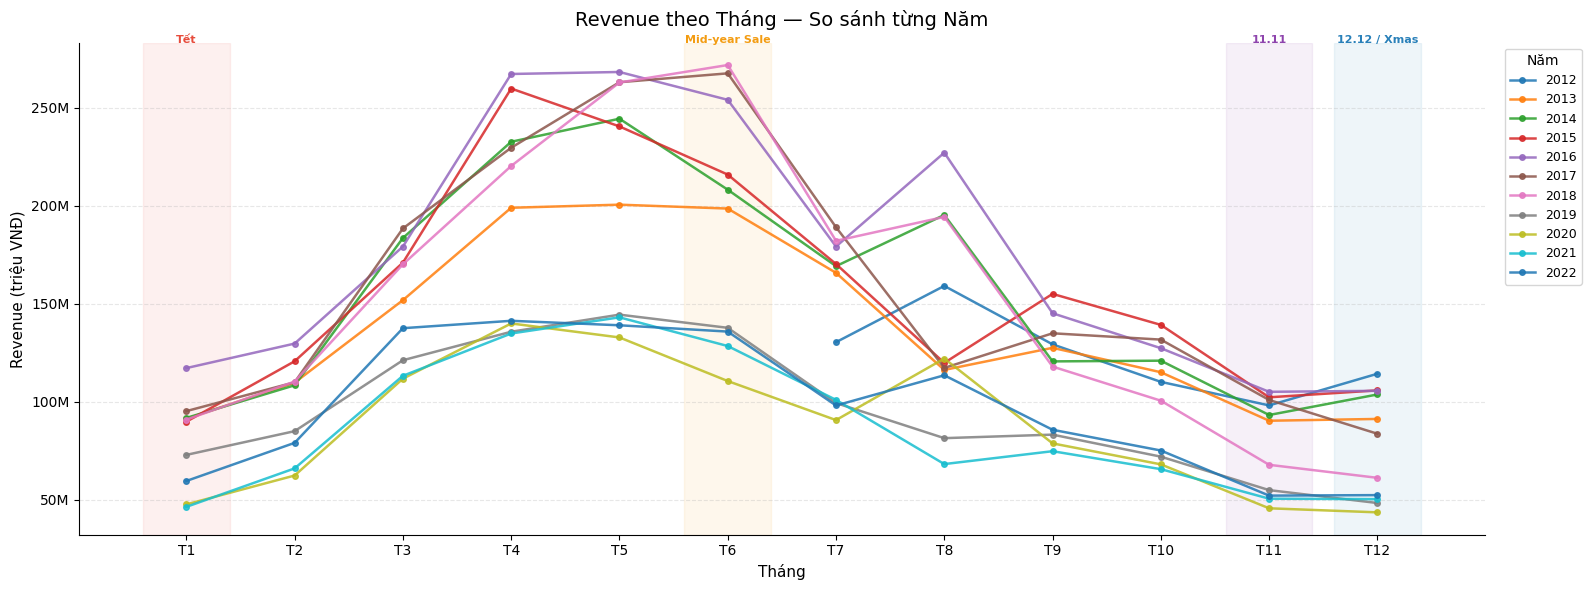

In [11]:
# ── Biểu đồ 1: Revenue theo tháng — mỗi năm một đường ─────────────
fig, ax1 = plt.subplots(figsize=(16, 6))
palette = sns.color_palette("tab10", n_colors=len(pivot.columns))
for i, year in enumerate(pivot.columns):
    ax1.plot(
        pivot.index, pivot[year] / 1e6,
        marker="o", markersize=4,
        linewidth=1.8,
        label=str(year),
        color=palette[i],
        alpha=0.85,
    )
# Đánh dấu sự kiện mùa vụ
for month, label, color in [
    (1,  "Tết",           "#e74c3c"),
    (6,  "Mid-year Sale", "#f39c12"),
    (11, "11.11",         "#8e44ad"),
    (12, "12.12 / Xmas",  "#2980b9"),
]:
    ax1.axvspan(month - 0.4, month + 0.4, alpha=0.08, color=color)
    ax1.text(month, ax1.get_ylim()[1],
             label, ha="center", fontsize=8, color=color, fontweight="bold")
ax1.set_title("Revenue theo Tháng — So sánh từng Năm", fontsize=14, pad=12)
ax1.set_xlabel("Tháng", fontsize=11)
ax1.set_ylabel("Revenue (triệu VNĐ)", fontsize=11)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([f"T{m}" for m in range(1, 13)])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}M"))
ax1.legend(title="Năm", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax1.grid(axis="y", alpha=0.3, linestyle="--")
ax1.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

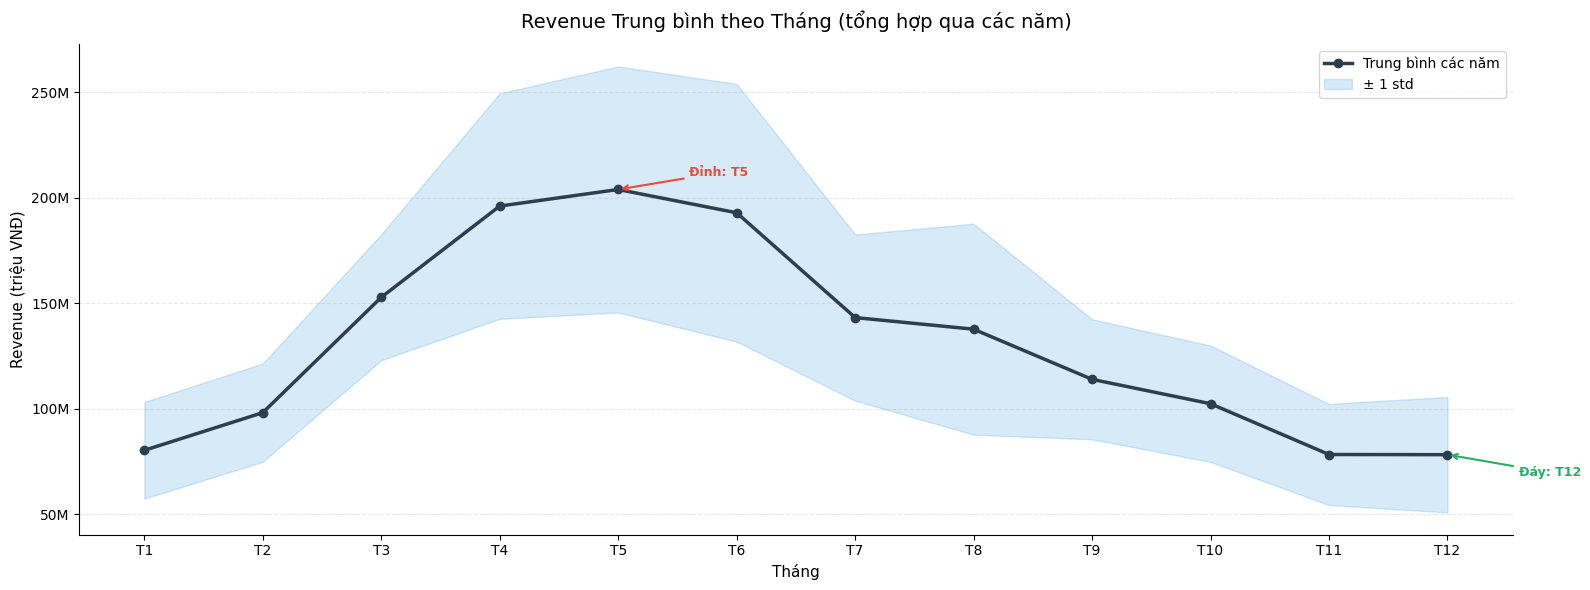

In [12]:
# ── Biểu đồ 2: Revenue trung bình ± std theo tháng ─────────────────
mean_by_month = pivot.mean(axis=1)
std_by_month  = pivot.std(axis=1)

fig, ax2 = plt.subplots(figsize=(16, 6))

ax2.plot(
    pivot.index, mean_by_month / 1e6,
    color="#2c3e50", linewidth=2.5, marker="o", markersize=6,
    label="Trung bình các năm"
)
ax2.fill_between(
    pivot.index,
    (mean_by_month - std_by_month) / 1e6,
    (mean_by_month + std_by_month) / 1e6,
    alpha=0.2, color="#3498db", label="± 1 std"
)

# Annotate đỉnh & đáy
peak_month = mean_by_month.idxmax()
low_month  = mean_by_month.idxmin()
y_range    = (mean_by_month.max() - mean_by_month.min()) / 1e6

ax2.annotate(
    f"Đỉnh: T{peak_month}",
    xy=(peak_month, mean_by_month[peak_month] / 1e6),
    xytext=(peak_month + 0.6, mean_by_month[peak_month] / 1e6 + y_range * 0.05),
    fontsize=9, color="#e74c3c", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=1.5),
)
ax2.annotate(
    f"Đáy: T{low_month}",
    xy=(low_month, mean_by_month[low_month] / 1e6),
    xytext=(low_month + 0.6, mean_by_month[low_month] / 1e6 - y_range * 0.08),
    fontsize=9, color="#27ae60", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#27ae60", lw=1.5),
)

ax2.set_title("Revenue Trung bình theo Tháng (tổng hợp qua các năm)", fontsize=14, pad=12)
ax2.set_xlabel("Tháng", fontsize=11)
ax2.set_ylabel("Revenue (triệu VNĐ)", fontsize=11)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels([f"T{m}" for m in range(1, 13)])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}M"))
ax2.legend(fontsize=10)
ax2.grid(axis="y", alpha=0.3, linestyle="--")
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


In [9]:
# ── 1. Phát hiện outlier bằng IQR ──────────────────────────────────
Q1  = df_sales["Revenue"].quantile(0.25)
Q3  = df_sales["Revenue"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_sales["is_outlier"] = (
    (df_sales["Revenue"] < lower) | (df_sales["Revenue"] > upper)
).astype(int)
outliers    = df_sales[df_sales["is_outlier"] == 1]
non_outlier = df_sales[df_sales["is_outlier"] == 0]
print(f"Thống kê Revenue:")
print(f"   Q1      : {Q1/1e6:,.2f}M")
print(f"   Q3      : {Q3/1e6:,.2f}M")
print(f"   IQR     : {IQR/1e6:,.2f}M")
print(f"   Ngưỡng dưới : {lower/1e6:,.2f}M")
print(f"   Ngưỡng trên : {upper/1e6:,.2f}M")
print(f"\nSố ngày outlier: {len(outliers)} / {len(df_sales)} ({len(outliers)/len(df_sales)*100:.1f}%)")


Thống kê Revenue:
   Q1      : 2.47M
   Q3      : 5.35M
   IQR     : 2.88M
   Ngưỡng dưới : -1.85M
   Ngưỡng trên : 9.67M

Số ngày outlier: 169 / 3833 (4.4%)


In [18]:
rev       = df_sales["Revenue"]
rev_log   = np.log1p(rev)          # log(1 + x) — tránh log(0)
rev_sqrt  = np.sqrt(rev)           # thử thêm sqrt transform
# ── 1. So sánh các chỉ số thống kê ────────────────────────────────
def describe_dist(series, name):
    return {
        "Transform":  name,
        "Mean":       f"{series.mean():,.2f}",
        "Std":        f"{series.std():,.2f}",
        "Skewness":   round(series.skew(), 4),      # 0 = phân phối chuẩn
        "Kurtosis":   round(series.kurtosis(), 4),  # 0 = chuẩn, >0 = đuôi nặng
        "Shapiro-W p": round(stats.shapiro(series.sample(500, random_state=42)).pvalue, 4),
    }
summary = pd.DataFrame([
    describe_dist(rev,      "Original"),
    describe_dist(rev_log,  "log1p"),
    describe_dist(rev_sqrt, "sqrt"),
])
print("So sánh phân phối sau các transform:")
print(summary.to_string(index=False))
print("\n Skewness gần 0 và Shapiro-W p > 0.05 → phân phối gần chuẩn hơn")

So sánh phân phối sau các transform:
Transform         Mean          Std  Skewness  Kurtosis  Shapiro-W p
 Original 4,286,584.03 2,624,840.20    1.6700    4.0303       0.0000
    log1p        15.10         0.59   -0.1594    0.1891       0.1999
     sqrt     1,986.17       584.63    0.7404    0.7572       0.0000

 Skewness gần 0 và Shapiro-W p > 0.05 → phân phối gần chuẩn hơn


In [13]:
revenue  = df_sales["Revenue"].dropna()
MAX_LAGS = 400 
# ── Tự động xác định lag quan trọng ──────────────────────────────
acf_vals,  conf_acf  = acf(revenue,  nlags=MAX_LAGS, alpha=0.05)
pacf_vals, conf_pacf = pacf(revenue, nlags=min(MAX_LAGS, len(revenue)//2 - 1),
                             method="ywm", alpha=0.05)

# Confidence interval (vùng xanh)
ci_acf  = conf_acf[:, 1]  - acf_vals   # half-width
ci_pacf = conf_pacf[:, 1] - pacf_vals

# Lọc các lag vượt ngoài CI
sig_acf  = [k for k in range(1, len(acf_vals))
            if abs(acf_vals[k]) > ci_acf[k]]
sig_pacf = [k for k in range(1, len(pacf_vals))
            if abs(pacf_vals[k]) > ci_pacf[k]]

print(f"Số lag có ý nghĩa (ACF):  {len(sig_acf)}")
print(f"Số lag có ý nghĩa (PACF): {len(sig_pacf)}")

# Nhóm theo các khoảng quan trọng
def check_lag(lag, sig_list, vals):
    if lag < len(vals):
        sig = "Có ý nghĩa" if lag in sig_list else "Không vượt CI"
        return f"lag_{lag:3d}: corr = {vals[lag]:+.4f}  -> {sig}"
    return f"lag_{lag:3d}: ngoài phạm vi"

print("\n Kiểm tra các lag phổ biến:")
for lag in [1, 2, 3, 6, 7, 14, 21, 28, 30, 60, 90, 180, 365]:
    print(f"  ACF  {check_lag(lag, sig_acf,  acf_vals)}")
    print(f"  PACF {check_lag(lag, sig_pacf, pacf_vals)}")
    print()


Số lag có ý nghĩa (ACF):  198
Số lag có ý nghĩa (PACF): 109

 Kiểm tra các lag phổ biến:
  ACF  lag_  1: corr = +0.8654  -> Có ý nghĩa
  PACF lag_  1: corr = +0.8654  -> Có ý nghĩa

  ACF  lag_  2: corr = +0.7350  -> Có ý nghĩa
  PACF lag_  2: corr = -0.0556  -> Có ý nghĩa

  ACF  lag_  3: corr = +0.6214  -> Có ý nghĩa
  PACF lag_  3: corr = -0.0076  -> Không vượt CI

  ACF  lag_  6: corr = +0.4673  -> Có ý nghĩa
  PACF lag_  6: corr = +0.3778  -> Có ý nghĩa

  ACF  lag_  7: corr = +0.4917  -> Có ý nghĩa
  PACF lag_  7: corr = +0.0186  -> Không vượt CI

  ACF  lag_ 14: corr = +0.4956  -> Có ý nghĩa
  PACF lag_ 14: corr = -0.0582  -> Có ý nghĩa

  ACF  lag_ 21: corr = +0.4356  -> Có ý nghĩa
  PACF lag_ 21: corr = +0.0204  -> Không vượt CI

  ACF  lag_ 28: corr = +0.6005  -> Có ý nghĩa
  PACF lag_ 28: corr = +0.1124  -> Có ý nghĩa

  ACF  lag_ 30: corr = +0.6482  -> Có ý nghĩa
  PACF lag_ 30: corr = +0.0831  -> Có ý nghĩa

  ACF  lag_ 60: corr = +0.4931  -> Có ý nghĩa
  PACF lag_ 60: cor

In [8]:

tables = {
    "sales":       pd.read_csv("Data/sales.csv"),
    "orders":      pd.read_csv("Data/orders.csv"),
    "order_items": pd.read_csv("Data/order_items.csv"),
    "payments":    pd.read_csv("Data/payments.csv"),
    "customers":   pd.read_csv("Data/customers.csv"),
    "products":    pd.read_csv("Data/products.csv"),
    "promotions":  pd.read_csv("Data/promotions.csv"),
    "inventory":   pd.read_csv("Data/inventory.csv"),
    "web_traffic": pd.read_csv("Data/web_traffic.csv"),
    "returns":     pd.read_csv("Data/returns.csv"),
    "reviews":     pd.read_csv("Data/reviews.csv"),
    "shipments":   pd.read_csv("Data/shipments.csv"),
    "geography":   pd.read_csv("Data/geography.csv"),
}

# ── In missing rate từng bảng ──────────────────────────────────────
for name, df in tables.items():
    missing = df.isnull().mean() * 100
    missing = missing[missing > 0].sort_values(ascending=False)
    
    if len(missing) == 0:
        print(f" {name:15s} — Không có missing")
    else:
        print(f"\n  {name:15s} ({len(df):,} dòng):")
        for col, pct in missing.items():
            print(f"   {col:30s}: {pct:5.1f}%")


C:\Users\Admin\AppData\Local\Temp\ipykernel_6320\4067678168.py:4: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  "order_items": pd.read_csv("Data/order_items.csv"),


 sales           — Không có missing
 orders          — Không có missing

  order_items     (714,669 dòng):
   promo_id_2                    : 100.0%
   promo_id                      :  61.3%
 payments        — Không có missing
 customers       — Không có missing
 products        — Không có missing

  promotions      (50 dòng):
   applicable_category           :  80.0%
 inventory       — Không có missing
 web_traffic     — Không có missing
 returns         — Không có missing
 reviews         — Không có missing
 shipments       — Không có missing
 geography       — Không có missing


In [15]:
df_web_daily = df_web.groupby("date").agg(
    sessions         = ("sessions",               "sum"),
    unique_visitors  = ("unique_visitors",         "sum"),
    page_views       = ("page_views",              "sum"),
    avg_bounce_rate  = ("bounce_rate",             "mean"),
    avg_session_dur  = ("avg_session_duration_sec","mean"),
).reset_index().rename(columns={"date": "Date"})
# Merge vào sales
df = df_sales.merge(df_web_daily, on="Date", how="left")
df = df.sort_values("Date").reset_index(drop=True)
print(f"Số ngày trong sales:      {len(df_sales)}")
print(f"Số ngày trong web_traffic: {len(df_web_daily)}")
print(f"Số ngày sau merge:         {len(df)}")
print(f"Missing sessions sau merge: {df['sessions'].isnull().sum()}")

Số ngày trong sales:      3833
Số ngày trong web_traffic: 3652
Số ngày sau merge:         3833
Missing sessions sau merge: 181


In [16]:
web_cols = ["sessions", "unique_visitors", "page_views", "avg_bounce_rate", "avg_session_dur"]
lags     = [0, 1, 2, 3, 5, 7, 14, 30]
results = []
for col in web_cols:
    for lag in lags:
        # lag > 0: web_traffic hôm nay → Revenue ngày lag sau
        # lag = 0: cùng ngày
        corr = df["Revenue"].corr(df[col].shift(lag))
        results.append({"feature": col, "lag": lag, "correlation": round(corr, 4)})
df_corr = pd.DataFrame(results)
# Pivot để xem dạng bảng
pivot_corr = df_corr.pivot(index="feature", columns="lag", values="correlation")
pivot_corr.columns = [f"lag_{c}" for c in pivot_corr.columns]
print("Cross-correlation: Web Traffic → Revenue (theo lag)")
print(pivot_corr.to_string())

Cross-correlation: Web Traffic → Revenue (theo lag)
                  lag_0   lag_1   lag_2   lag_3   lag_5   lag_7  lag_14  lag_30
feature                                                                        
avg_bounce_rate -0.0206 -0.0173 -0.0016  0.0030  0.0130 -0.0146 -0.0235 -0.0175
avg_session_dur -0.0256 -0.0214 -0.0262 -0.0087 -0.0004 -0.0069 -0.0035 -0.0150
page_views       0.3016  0.3055  0.2949  0.2846  0.2863  0.2865  0.2643  0.1994
sessions         0.3211  0.3216  0.3159  0.3119  0.3129  0.3092  0.2885  0.2132
unique_visitors  0.3188  0.3185  0.3113  0.3046  0.3093  0.3073  0.2870  0.2149
